In [2]:
%matplotlib inline

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.utils import resample
import seaborn as sns
import pandas as pd

def auc_CI(model_name, y_true, y_scores):
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    original_auc = auc(fpr, tpr)

    # Bootstrapping
    n_bootstraps = 1000
    bootstrapped_aucs = []
    np.random.seed(233)
    for i in range(n_bootstraps):
        # Bootstrap by sampling with replacement on the prediction indices
        indices = np.random.randint(0, len(y_scores), len(y_scores))
        fpr_boot, tpr_boot, _ = roc_curve(y_true[indices], y_scores[indices])
        roc_auc_boot = auc(fpr_boot, tpr_boot)
        bootstrapped_aucs.append(roc_auc_boot)
    lower_bound, upper_bound = np.percentile(bootstrapped_aucs, [2.5, 97.5])
    # print("{} —— Confidence interval for the AUC score: [{:0.3f} - {:0.3f}]".format(
    # model_name, lower_bound, upper_bound))
    
    return lower_bound, upper_bound

def roc_curve_CI_band(model_name, y_true, y_scores):
    # Calculate the initial AUROC
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
#     print(thresholds)
    original_auc = auc(fpr, tpr)

    # Bootstrapping
    n_bootstraps = 1000
    bootstrapped_aucs = []
    indices_log = []
    np.random.seed(233)
    for i in range(n_bootstraps):
        # Bootstrap by sampling with replacement on the prediction indices
        indices = np.random.randint(0, len(y_scores), len(y_scores))
        fpr_boot, tpr_boot, _ = roc_curve(y_true[indices], y_scores[indices])
        roc_auc_boot = auc(fpr_boot, tpr_boot)
        bootstrapped_aucs.append(roc_auc_boot)
        indices_log.append(indices)
    sorted_scores = np.argsort(bootstrapped_aucs)

    # Computing the lower and upper bound of the 95% confidence interval
    confidence_lower = sorted_scores[int(0.025 * len(sorted_scores))]
    confidence_upper = sorted_scores[int(0.975 * len(sorted_scores))]
    print("{} —— Confidence interval for the AUC score: [{:0.3f} - {:0.3}]".format(model_name,
        bootstrapped_aucs[confidence_lower], bootstrapped_aucs[confidence_upper]))
    # # Calculate confidence interval
    # lower_bound, upper_bound = np.percentile(bootstrapped_aucs, [2.5, 97.5])
    # print(lower_bound, upper_bound)

    tprs_lower = []
    fprs_lower = []
    tprs_upper = []
    fprs_upper = []
    # Calculate and plot ROC curve for each threshold
    for i, threshold in enumerate(thresholds):
        # Convert predicted probabilities to binary predictions using the current threshold
        y_pred = np.where(y_scores >= threshold, 1, 0)
        # Calculate true positive rate (tpr) and false positive rate (fpr)
        fpr_lower, tpr_lower, _ = roc_curve(y_true[indices_log[confidence_lower]], y_pred[indices_log[confidence_lower]])
        fpr_upper, tpr_upper, _ = roc_curve(y_true[indices_log[confidence_upper]], y_pred[indices_log[confidence_upper]])
#         print(fpr_lower[1], tpr_lower[1], fpr_upper[1], tpr_upper[1])
        # Append tpr and fpr to the lists
        if tpr_lower[1] >= 1 and len(tprs_lower) < 3:
            tprs_lower.append(0)
            fprs_lower.append(0)
            tprs_upper.append(0)
            fprs_upper.append(0)
        else:
            if tpr_lower[1] > tpr[i]:
                tprs_lower.append(tpr[i])
            else:
                tprs_lower.append(tpr_lower[1])
            if tpr_upper[1] < tpr[i]:
                tprs_upper.append(tpr[i])
            else:
                tprs_upper.append(tpr_upper[1]) 
        
        
    return fpr, tpr, original_auc, tprs_lower, tprs_upper



In [91]:
with open('NODE21_NIH_allmappings.txt', 'r') as f:
    lines = f.readlines()
    nih_mappings = {}
    for line in lines:
        parts = line.strip().split()
        nih_mappings[parts[0]] = parts[1]
normal_images = [name for name in nih_mappings.values() if name[0]=='c']
len(normal_images)

1016

XRV-DenseNet —— Confidence interval for the AUC score: [0.496 - 0.55]
XRV-ResNet —— Confidence interval for the AUC score: [0.643 - 0.694]
KAD —— Confidence interval for the AUC score: [0.810 - 0.851]
ELIXR —— Confidence interval for the AUC score: [0.567 - 0.624]
Ark+ —— Confidence interval for the AUC score: [0.885 - 0.916]


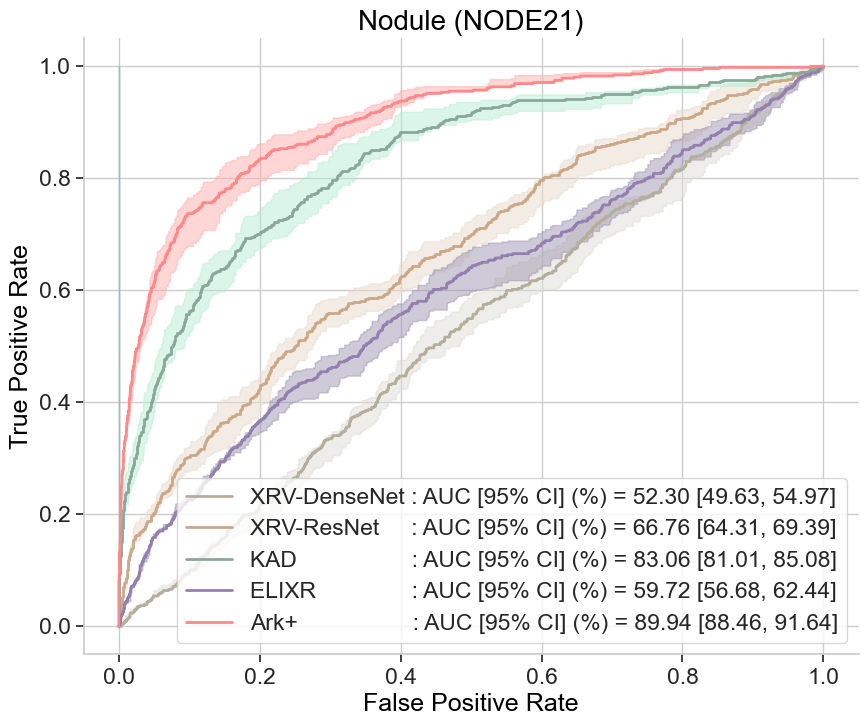

In [ ]:
model_name = "Ark+"
df = pd.read_csv("zeroshot_pred_csv/Ark6_SwinL768_Nodule21processed_excludeNIH_ZeroShotPred.csv")
model_name2 = "XRV-ResNet"
df2 = pd.read_csv("zeroshot_pred_csv/ResNet50_512_Nodule21processed_excludeNIH_ZeroShotPred.csv")
model_name3 = "XRV-DenseNet"
df3 = pd.read_csv("zeroshot_pred_csv/DenseNet224all_Nodule21processed_excludeNIH_ZeroShotPred.csv")
model_name4 = "KAD"
df4 = pd.read_csv("zeroshot_pred_csv/KAD_Nodule21processed_excludeNIH_ZeroShotPred.csv")
model_name5 = "ELIXR"
df5 = pd.read_csv("zeroshot_pred_csv/ELIXR_Nodule21processed_excludeNIH_ZeroShotPred.csv")

# remove 1016 normal images from NIH
df = df[~df['img_path'].str.contains('|'.join(normal_images))]
df2 = df2[~df2['img_path'].str.contains('|'.join(normal_images))]
df3 = df3[~df3['img_path'].str.contains('|'.join(normal_images))]
df4 = df4[~df4['image_name'].str.contains('|'.join(normal_images))]
df5 = df5[~df5['image_name'].str.contains('|'.join(normal_images))]

y_true = np.array(df['Node21'])
y_scores = np.array(df['Nodule'])
y_true2 = np.array(df2['Node21'])
y_scores2 = np.array(df2['Nodule'])
y_true3 = np.array(df3['Node21'])
y_scores3 = np.array(df3['Nodule'])
y_true4 = np.array(df4['ground_truth'])
y_scores4 = np.array(df4['prediction'])
y_true5 = np.array(df5['ground_truth'])
y_scores5 = np.array(df5['prediction'])

# Plot ROC curve
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid" , font_scale=1.5, 
              rc={'xtick.bottom': True,
                    'ytick.left': True,
                    'font.sans-serif':'Arial',
                    'pdf.fonttype':42
                    })

fpr, tpr, original_auc, tprs_lower, tprs_upper = roc_curve_CI_band(model_name3, y_true3, y_scores3)
lower_bound, upper_bound = auc_CI(model_name3, y_true3, y_scores3)
plt.plot(fpr, tpr, color='#b6ae9c', lw=2, label='{:10} : AUC [95% CI] (%) = {:.2f} [{:.2f}, {:.2f}]'.format("XRV-DenseNet", original_auc*100,lower_bound*100,upper_bound*100))
# Plot Confidence Interval Band
plt.fill_between(fpr, tprs_lower, tprs_upper, color='#e0dcd4', alpha=0.5)

fpr, tpr, original_auc, tprs_lower, tprs_upper = roc_curve_CI_band(model_name2, y_true2, y_scores2)
lower_bound, upper_bound = auc_CI(model_name2, y_true2, y_scores2)
plt.plot(fpr, tpr, color='#cca887', lw=2, label='{:14} : AUC [95% CI] (%) = {:.2f} [{:.2f}, {:.2f}]'.format("XRV-ResNet", original_auc*100,lower_bound*100,upper_bound*100))
# Plot Confidence Interval Band
plt.fill_between(fpr, tprs_lower, tprs_upper, color='#e9dacc', alpha=0.5)

fpr, tpr, original_auc, tprs_lower, tprs_upper = roc_curve_CI_band(model_name4, y_true4, y_scores4)
lower_bound, upper_bound = auc_CI(model_name4, y_true4, y_scores4)
plt.plot(fpr, tpr, color='#8aa899', lw=2, label='{:20} : AUC [95% CI] (%) = {:.2f} [{:.2f}, {:.2f}]'.format("KAD", original_auc*100,lower_bound*100,upper_bound*100))
# Plot Confidence Interval Band
plt.fill_between(fpr, tprs_lower, tprs_upper, color='#b8eed4', alpha=0.5)

fpr, tpr, original_auc, tprs_lower, tprs_upper = roc_curve_CI_band(model_name5, y_true5, y_scores5)
lower_bound, upper_bound = auc_CI(model_name5, y_true5, y_scores5)
plt.plot(fpr, tpr, color='#9480b0', lw=2, label='{:19} : AUC [95% CI] (%) = {:.2f} [{:.2f}, {:.2f}]'.format("ELIXR", original_auc*100,lower_bound*100,upper_bound*100))
# Plot Confidence Interval Band
plt.fill_between(fpr, tprs_lower, tprs_upper, color='#a096b0', alpha=0.5)

fpr, tpr, original_auc, tprs_lower, tprs_upper = roc_curve_CI_band(model_name, y_true, y_scores)
lower_bound, upper_bound = auc_CI(model_name, y_true, y_scores)
plt.plot(fpr, tpr, color='#ff8888', lw=2, label='{:21} : AUC [95% CI] (%) = {:.2f} [{:.2f}, {:.2f}]'.format("Ark+", original_auc*100,lower_bound*100,upper_bound*100))
# Plot Confidence Interval Band
plt.fill_between(fpr, tprs_lower, tprs_upper, color='#ffafaf', alpha=0.5)

plt.xlabel('False Positive Rate', fontsize=18, color='black' )
plt.ylabel('True Positive Rate', fontsize=18, color='black')
plt.title('Nodule (NODE21)', fontsize=20, color='black')
sns.despine(left=False, right=True)
plt.legend(loc='lower right')
# plt.savefig("zeroshot_node21_revision.pdf",dpi=1000)
plt.show()


KAD —— Confidence interval for the AUC score: [0.915 - 0.942]
Ark+ —— Confidence interval for the AUC score: [0.969 - 0.981]


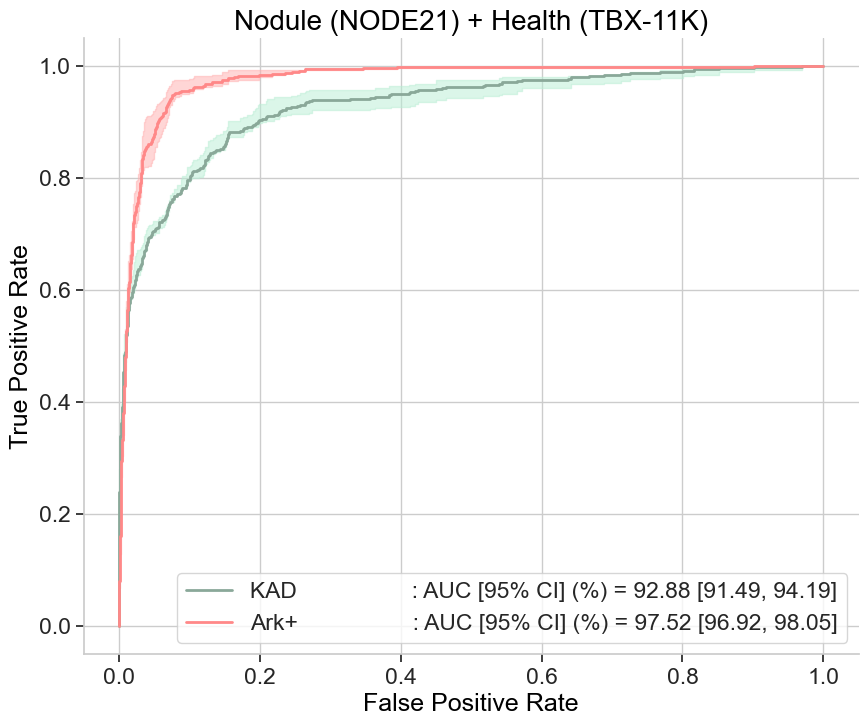

In [84]:
model_name = "Ark+"
df = pd.read_csv("zeroshot_pred_csv/Ark6_SwinL768_Nodule21processed_excludeNIH_ZeroShotPred.csv")
model_name4 = "KAD"
df4 = pd.read_csv("zeroshot_pred_csv/KAD_Nodule21processed_excludeNIH_ZeroShotPred.csv")

ddf = pd.read_csv("zeroshot_pred_csv/Ark6_swinL768_TBX11K_TBvsSickHealth_ZeroShotPred.csv")
ddf4 = pd.read_csv("zeroshot_pred_csv/KAD_TBX11k.csv")
df_normal = ddf[ddf['img_path'].str.contains('health')]
df_normal4 = ddf4[ddf4['image_name'].str.contains('health')]
df_normal = df_normal[:3748] # Match the number of normal images to that of NODE21
df_normal4 = df_normal4[:3748]

df_nodule = df[df['Node21']==1] # Select nodule data from NODE21: Openl 54 + JSRT 149 + Padchest 314 = 517 Nodule images
df_nodule = df_nodule[['Nodule', 'Node21']].rename(columns={'Node21': 'ground_truth'})
df_normal = df_normal[['Nodule', 'TBX-11K']].rename(columns={'TBX-11K': 'ground_truth'})
df = pd.concat([df_nodule, df_normal], ignore_index=True) # Combine nodule and normal data

df_nodule4 = df4[df4['ground_truth']==1] # Select nodule data from NODE21: Openl 54 + JSRT 149 + Padchest 314 = 517 Nodule images
df4 = pd.concat([df_nodule4, df_normal4], ignore_index=True) # Combine nodule and normal data

y_true = np.array(df['ground_truth'])
y_scores = np.array(df['Nodule'])

y_true4 = np.array(df4['ground_truth'])
y_scores4 = np.array(df4['prediction'])

# Plot ROC curve
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid" , font_scale=1.5, 
              rc={'xtick.bottom': True,
                    'ytick.left': True,
                    'font.sans-serif':'Arial',
                    'pdf.fonttype':42
                    })


fpr, tpr, original_auc, tprs_lower, tprs_upper = roc_curve_CI_band(model_name4, y_true4, y_scores4)
lower_bound, upper_bound = auc_CI(model_name4, y_true4, y_scores4)
plt.plot(fpr, tpr, color='#8aa899', lw=2, label='{:20} : AUC [95% CI] (%) = {:.2f} [{:.2f}, {:.2f}]'.format("KAD", original_auc*100,lower_bound*100,upper_bound*100))
# Plot Confidence Interval Band
plt.fill_between(fpr, tprs_lower, tprs_upper, color='#b8eed4', alpha=0.5)

fpr, tpr, original_auc, tprs_lower, tprs_upper = roc_curve_CI_band(model_name, y_true, y_scores)
lower_bound, upper_bound = auc_CI(model_name, y_true, y_scores)
plt.plot(fpr, tpr, color='#ff8888', lw=2, label='{:21} : AUC [95% CI] (%) = {:.2f} [{:.2f}, {:.2f}]'.format("Ark+", original_auc*100,lower_bound*100,upper_bound*100))
# Plot Confidence Interval Band
plt.fill_between(fpr, tprs_lower, tprs_upper, color='#ffafaf', alpha=0.5)

plt.xlabel('False Positive Rate', fontsize=18, color='black' )
plt.ylabel('True Positive Rate', fontsize=18, color='black')
plt.title('Nodule (NODE21) + Health (TBX-11K)', fontsize=20, color='black')
sns.despine(left=False, right=True)
plt.legend(loc='lower right')
# plt.savefig("zeroshot_node21_revision.pdf",dpi=1000)
plt.show()
